In [620]:
import os
from pathlib import Path
import h5py
import matplotlib.pyplot as plt
import numpy as np

# 1. Define the path to the outputs directory
output_dir = Path("../outputs/exorem")
h5_file_path = output_dir / "outputexample_R50_no_irr.h5"

if not h5_file_path.exists():
    # Fallback to current directory check if run locally in alternative paths
    h5_file_path = Path("outputexample_R50_no_irr.h5")

# 2. Extract arrays from the consolidated ExoREM HDF5 data tree
with h5py.File(h5_file_path, "r") as hf:
    print(hf['outputs']['spectra']['emission'].keys())
    pressures_pa = hf['outputs']['layers']["pressure"][:]
    temperatures = hf['outputs']['layers']["temperature"][:]
    wavenumbers = hf['outputs']['spectra']["wavenumber"][:]
    # Emergent thermal radiosity is at the Top-Of-Atmosphere boundary layer (last index)
    spectral_radiosity = hf["spectral_radiosity"][-1, :] 

# 3. Apply standard physical conversions
pressures_bar = pressures_pa / 1e5       # Convert Pa -> bar
wavelengths_um = 10000.0 / wavenumbers   # Convert Wavenumber (cm⁻¹) -> Wavelength (µm)

# 4. Generate the 3-panel visualization suite
fig, axs = plt.subplots(1, 3, figsize=(16, 5.5))

# Panel A: Atmospheric Temperature-Pressure Structure
axs[0].plot(temperatures, pressures_bar, color='firebrick', lw=2.5)
axs[0].set_yscale('log')
axs[0].invert_yaxis()  # Pressure decreases as altitude increases
axs[0].set_xlabel('Temperature (K)', fontsize=12)
axs[0].set_ylabel('Pressure (bar)', fontsize=12)
axs[0].set_title('Temperature-Pressure Profile', fontsize=13, fontweight='bold')
axs[0].grid(True, which="both", ls="--", alpha=0.5)

# Panel B: Emergent Thermal Spectrum vs Wavenumber
axs[1].plot(wavenumbers, spectral_radiosity, color='royalblue', lw=1.5)
axs[1].set_xlabel(r'Wavenumber ($\mathrm{cm}^{-1}$)', fontsize=12)
axs[1].set_ylabel(r'Spectral Radiosity ($\mathrm{erg\ s}^{-1}\mathrm{\ cm}^{-2}\mathrm{\ sr}^{-1}\ /\ \mathrm{cm}^{-1}$)', fontsize=11)
axs[1].set_title('Emergent Spectrum vs Wavenumber', fontsize=13, fontweight='bold')
axs[1].grid(True, ls="--", alpha=0.5)
axs[1].set_yscale('log')

# Panel C: Emergent Thermal Spectrum vs Wavelength (Log-Scale)
axs[2].plot(wavelengths_um, spectral_radiosity, color='forestgreen', lw=1.5)
axs[2].set_xlabel(r'Wavelength ($\mu\mathrm{m}$)', fontsize=12)
axs[2].set_ylabel(r'Spectral Radiosity ($\mathrm{erg\ s}^{-1}\mathrm{\ cm}^{-2}\mathrm{\ sr}^{-1}\ /\ \mathrm{cm}^{-1}$)', fontsize=11)
axs[2].set_title('Emergent Spectrum vs Wavelength', fontsize=13, fontweight='bold')
axs[2].grid(True, which="both", ls="--", alpha=0.5)
axs[2].set_xscale('log')
axs[2].set_xticks([0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0])
axs[2].get_xaxis().set_major_formatter(plt.ScalarFormatter())
axs[2].set_yscale('log')
axs[2].set_xlim(1,15)
axs[2].set_ylim(1e-1,5000)

plt.tight_layout()
plt.show()

<KeysViewHDF5 ['spectral_radiosity']>


KeyError: "Unable to synchronously open object (object 'spectral_radiosity' doesn't exist)"

In [610]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np

# Load data
df = pd.read_csv("../outputs/exorem/iteration_profiles.csv")

# Sorted unique iterations
iterations = np.sort(df.iteration.unique())

# Create colormap normalization
cmap = cm.viridis   # try also: plasma, inferno, turbo, cividis
norm = mcolors.Normalize(vmin=iterations.min(), vmax=iterations.max())

# Plot
fig, ax = plt.subplots()

for it in iterations:
    sub = df[df.iteration == it].sort_values("pressure_Pa")

    ax.semilogy(
        sub.temperature_K,
        sub.pressure_Pa,
        color=cmap(norm(it)),
        label=f"iter {it}"
    )

ax.invert_yaxis()

ax.set_xlabel("T (K)")
ax.set_ylabel("p (Pa)")

# Optional: colorbar instead of huge legend
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Iteration")

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../outputs/exorem/iteration_profiles.csv'

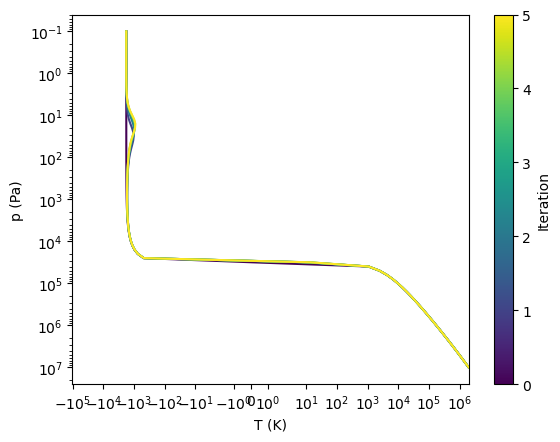

In [355]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np

sigma = 5.67 *1e-8

# Load data
df = pd.read_csv("../outputs/exorem/iteration_profiles.csv")

# Sorted unique iterations
iterations = np.sort(df.iteration.unique())

# Create colormap normalization
cmap = cm.viridis   # try also: plasma, inferno, turbo, cividis
norm = mcolors.Normalize(vmin=iterations.min(), vmax=iterations.max())

# Plot
fig, ax = plt.subplots()

for it in iterations:
    sub = df[df.iteration == it].sort_values("pressure_Pa")

    ax.plot(
        (sigma*sub.temperature_K**4-sigma*500**4),
        sub.pressure_Pa,
        color=cmap(norm(it)),
        label=f"iter {it}"
    )

ax.invert_yaxis()

ax.set_xlabel("T (K)")
ax.set_ylabel("p (Pa)")
ax.set_yscale('log')
ax.set_xscale('symlog')

# Optional: colorbar instead of huge legend
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Iteration")

plt.show()

In [1025]:
import numba
print(f"Numba version: {numba.__version__}")

Numba version: 0.60.0


In [217]:
numba.get_num_threads()


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


8

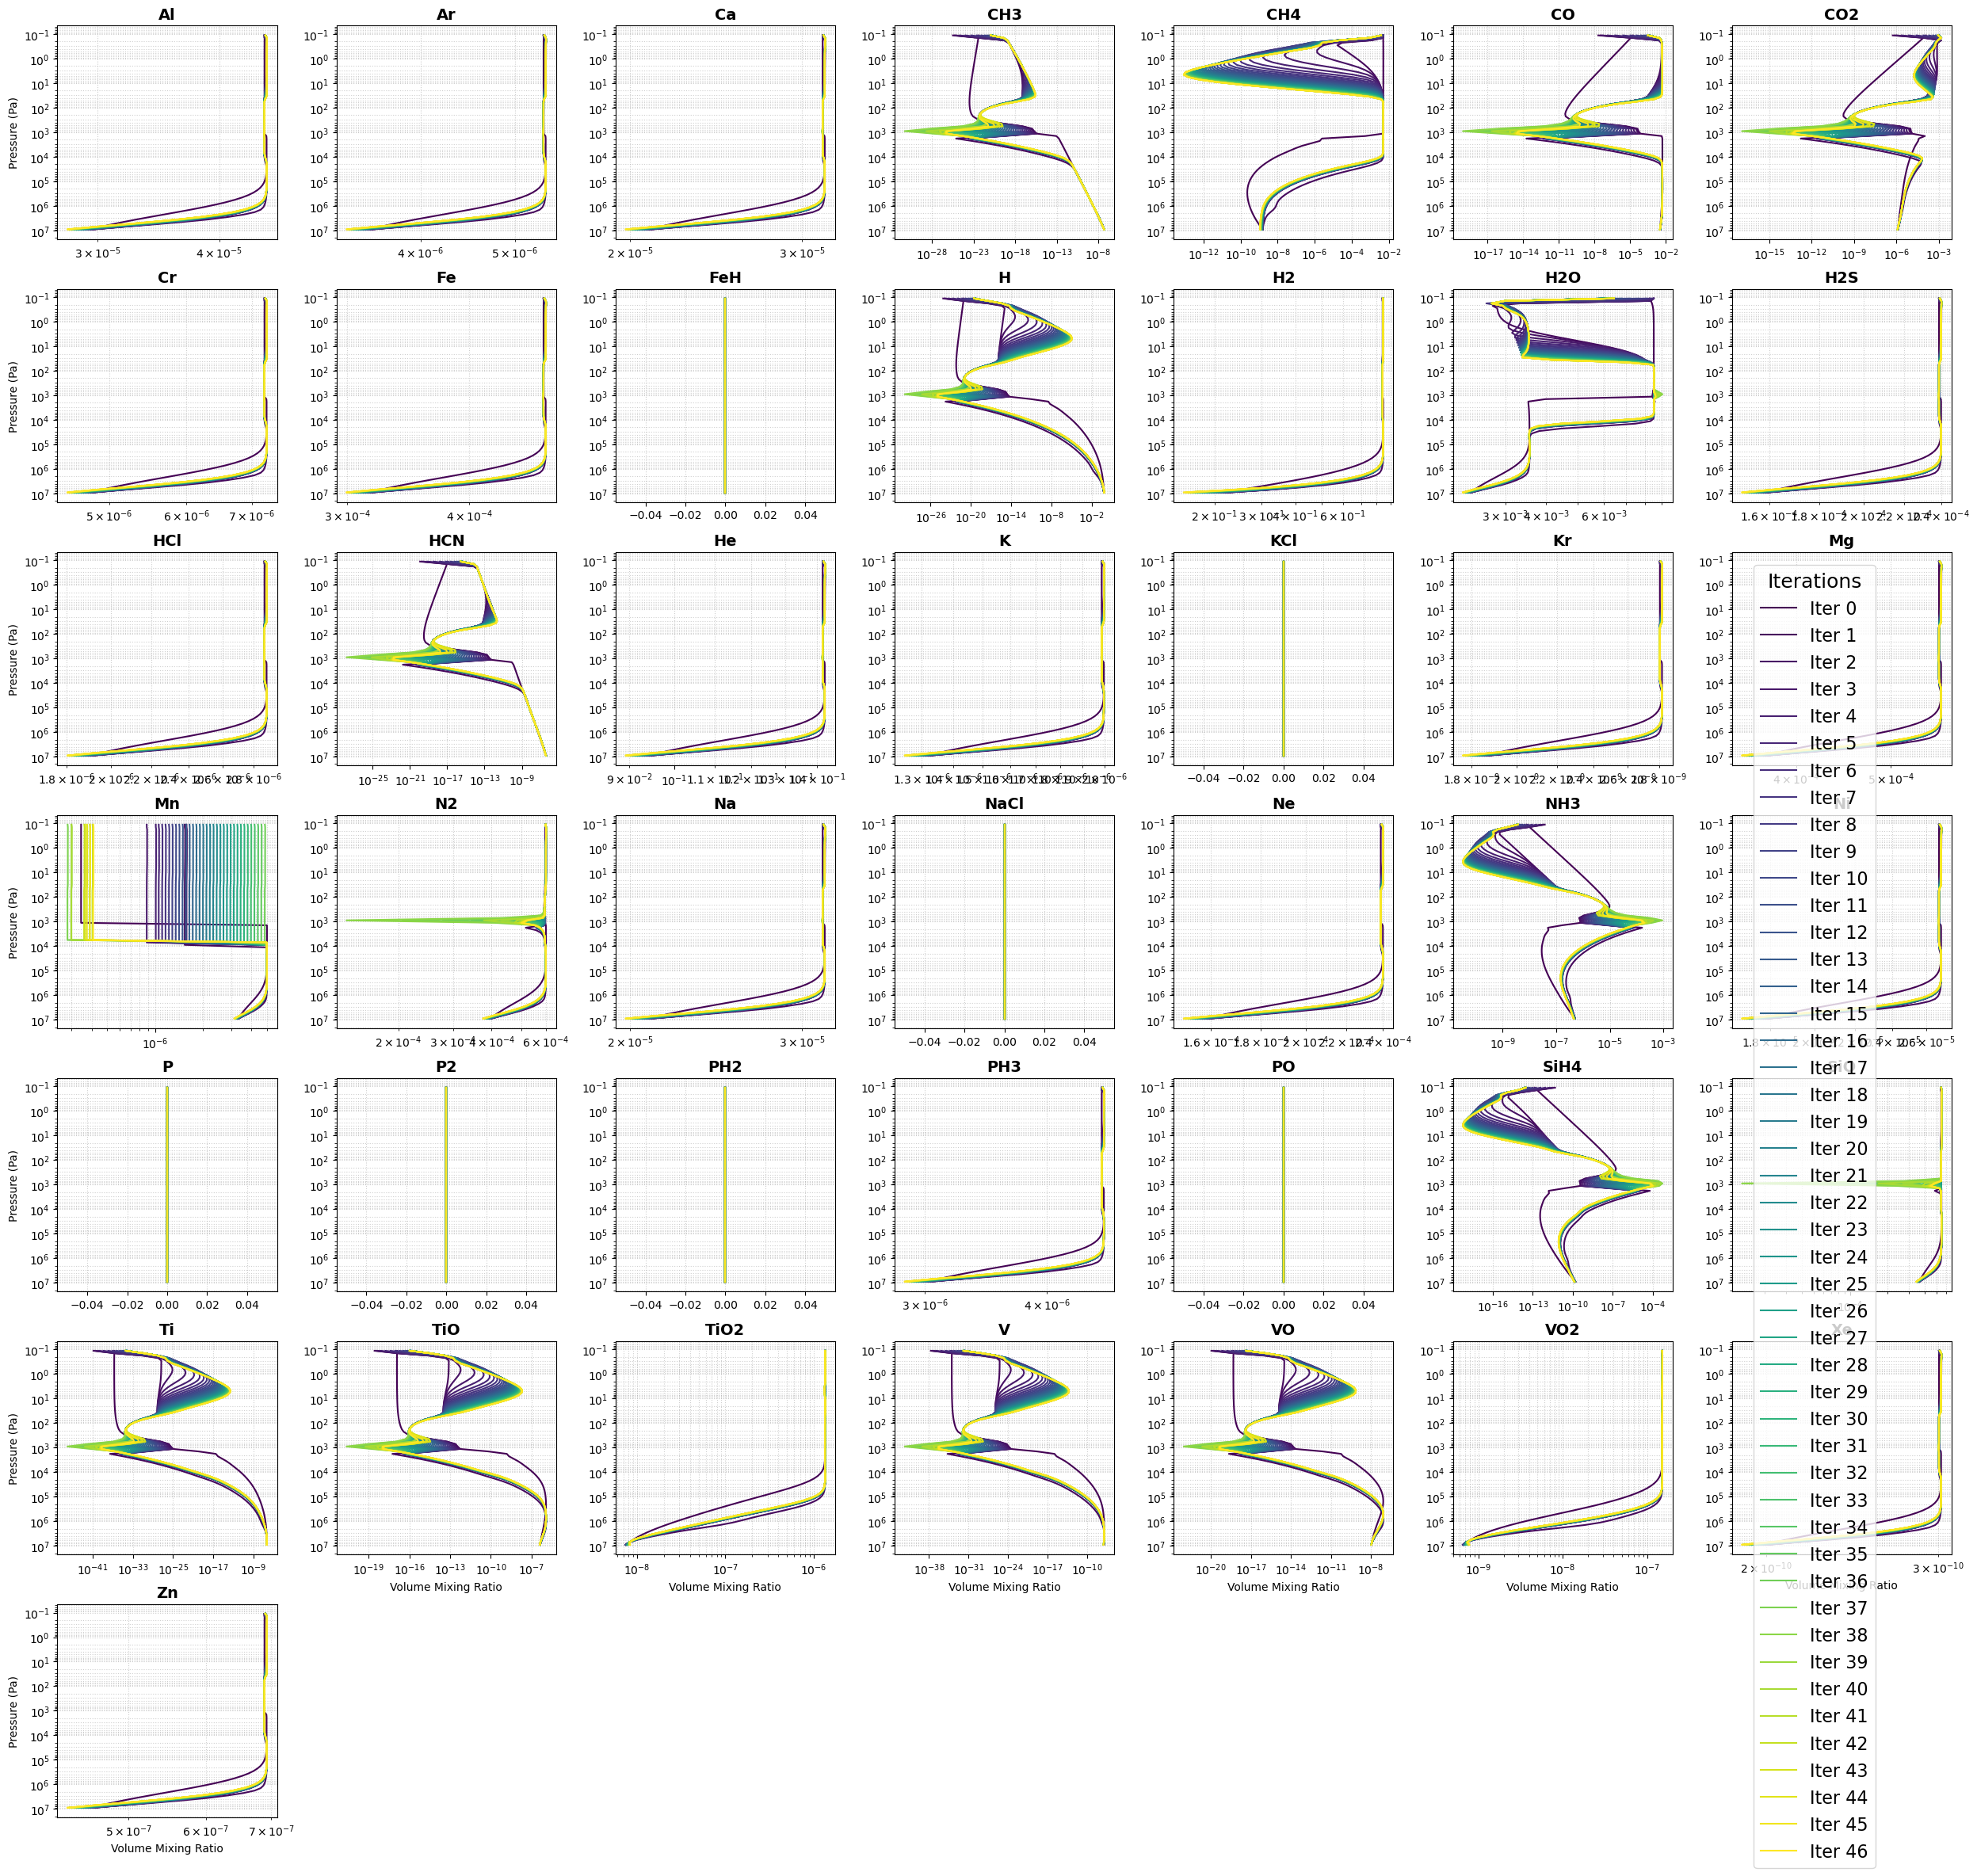

In [328]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math

# 1. Load the joined dataset
df = pd.read_csv('../outputs/exorem/iteration_vmrs.csv')

# 2. Extract species names (ignoring the first 6 metadata columns)
species = df.columns[6:]
n_species = len(species)

# 3. Determine grid size for subplots (e.g., 7x7 for ~43 species)
cols = math.ceil(math.sqrt(n_species))
rows = math.ceil(n_species / cols)

fig, axes = plt.subplots(rows, cols, figsize=(25, 25))
axes = axes.flatten()

# 4. Get unique iterations and set up a colormap
iterations = sorted(df['iteration'].unique())
colors = plt.cm.viridis(np.linspace(0, 1, len(iterations)))

# 5. Plot each species in its own subplot
for i, sp in enumerate(species):
    ax = axes[i]
    
    for it, color in zip(iterations, colors):
        subset = df[df['iteration'] == it]
        # Plot VMR on X-axis and Pressure on Y-axis
        ax.plot(subset[sp], subset['pressure_Pa'], color=color, label=f'Iter {it}')
    
    # Pressure is conventionally plotted on an inverted log scale
    ax.set_yscale('log')
    ax.invert_yaxis()
    
    # Use log scale for VMR if the values span multiple orders of magnitude
    non_zero_min = subset[sp][subset[sp] > 0].min()
    if pd.notna(non_zero_min) and subset[sp].max() > 0:
        ax.set_xscale('log')
        
    ax.set_title(sp, fontsize=14, fontweight='bold')
    ax.grid(True, which='both', linestyle=':', alpha=0.6)
    
    # Add labels to outer plots to avoid clutter
    if i % cols == 0:
        ax.set_ylabel('Pressure (Pa)', fontsize=10)
    if i >= n_species - cols:
        ax.set_xlabel('Volume Mixing Ratio', fontsize=10)

# 6. Create a single master legend in the bottom right corner
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', fontsize=16, 
           title='Iterations', title_fontsize=18, bbox_to_anchor=(0.95, 0.05))

# 7. Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
fig.subplots_adjust(bottom=0.08) # Make room for the legend
plt.savefig('species_evolution_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

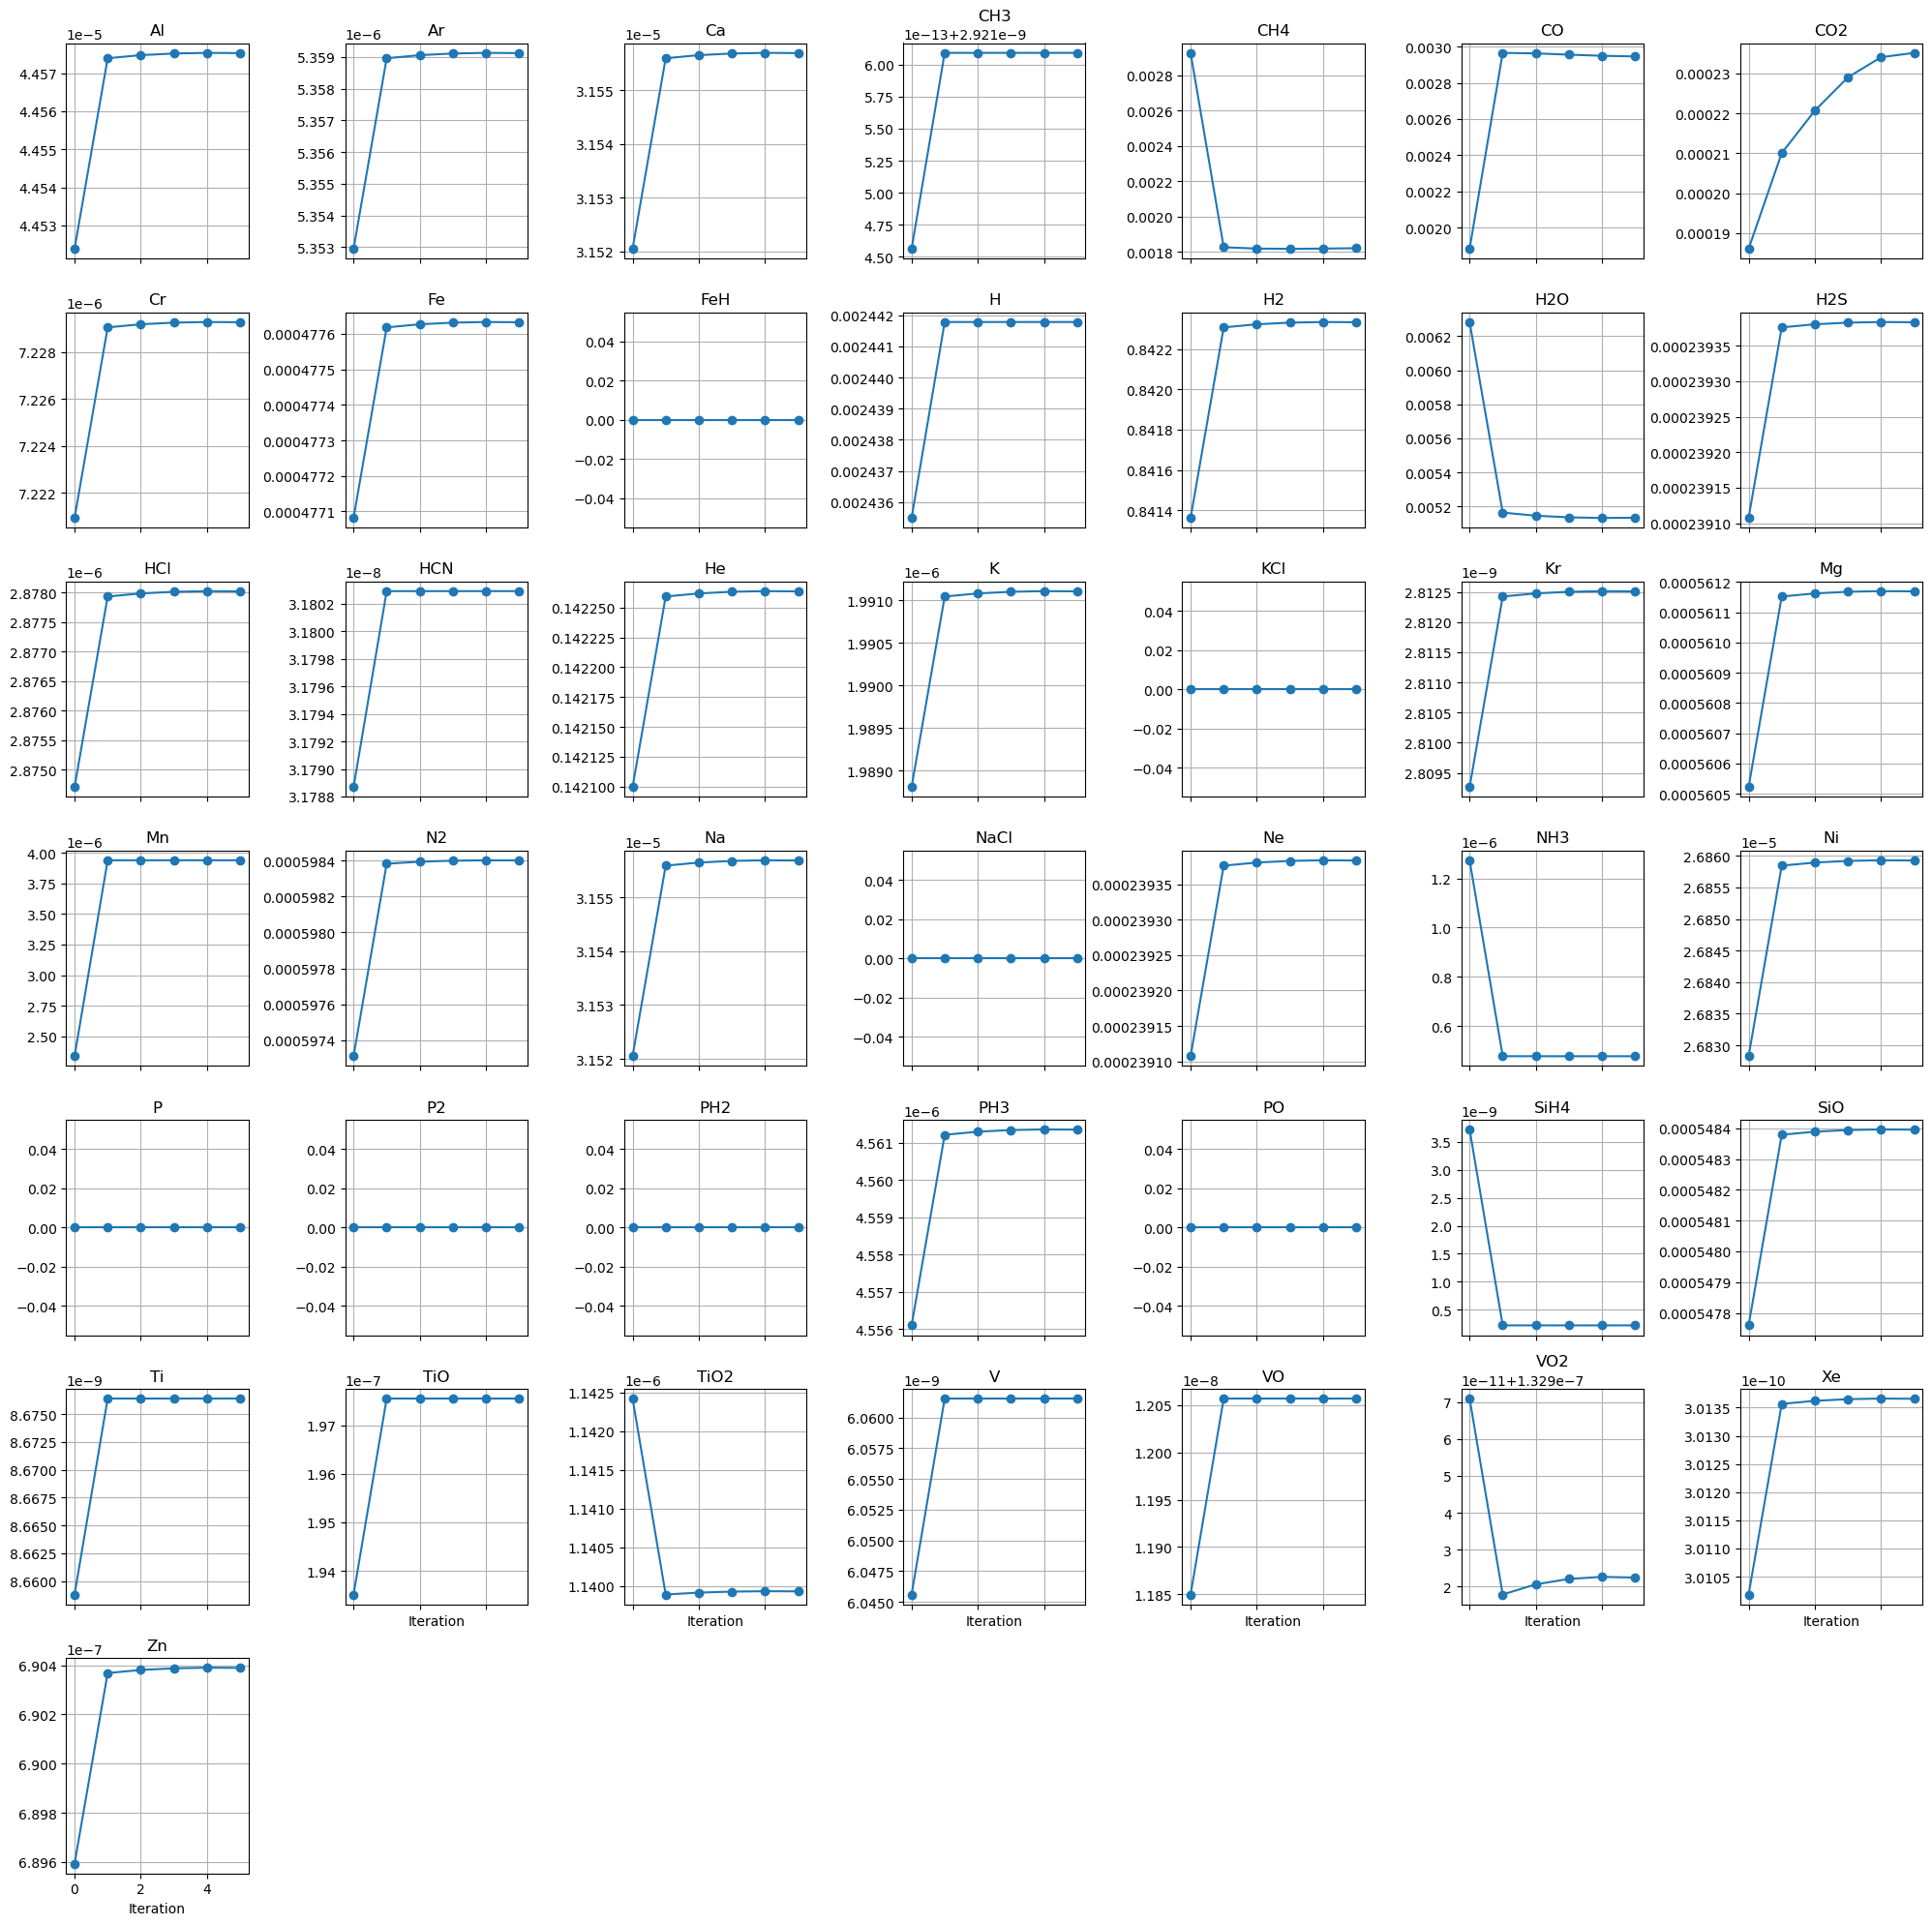

In [246]:
# Group by iteration and take the mean across all levels
mean_df = df.groupby('iteration')[species].mean()

fig, axes = plt.subplots(rows, cols, figsize=(20, 20), sharex=True)
axes = axes.flatten()

for i, sp in enumerate(species):
    ax = axes[i]
    ax.plot(mean_df.index, mean_df[sp], marker='o', linestyle='-')
    ax.set_title(sp)
    ax.grid(True)
    
    if i >= n_species - cols:
        ax.set_xlabel('Iteration')
        
# Clear empty plots and save
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('mean_vmr_vs_iteration.png')
plt.show()